**Taller 3 Modelos_Espaciales_Espacio_temporal**

Luis Alberto Castillo Sanabria

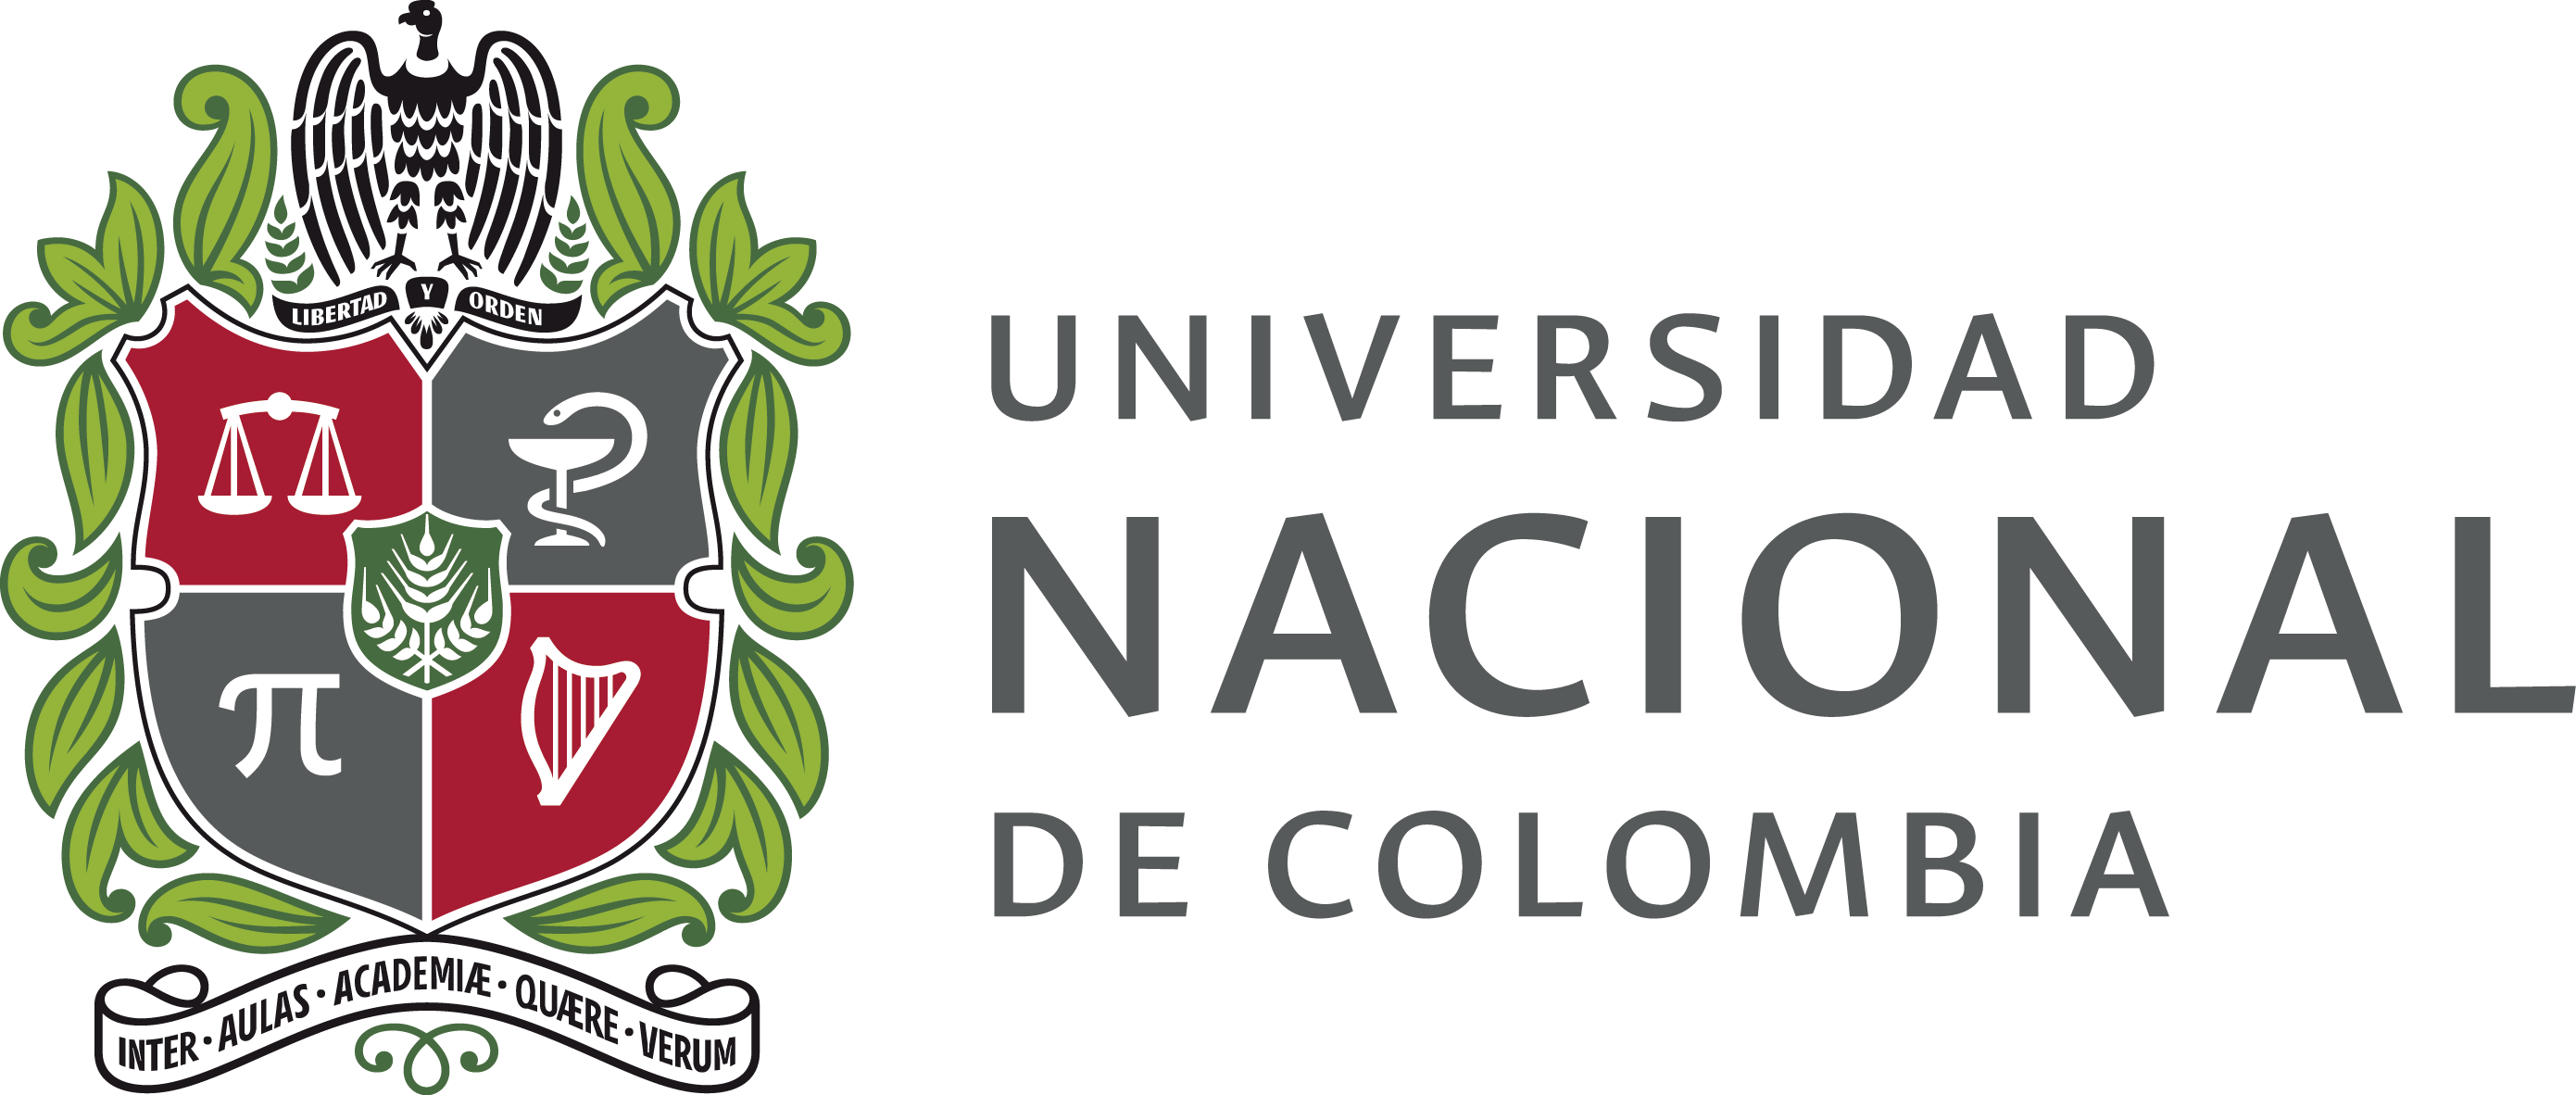


1. **Preparación de datos y construcción del GeoDataFrame**

Para iniciar el análisis se cargó la base de datos de *Colletotrichum* en mango de azúcar (años 2020–2024) desde un archivo Excel y se transformó en un objeto espacial (GeoDataFrame). A partir de las columnas de latitud y longitud se generaron puntos georreferenciados en el sistema de referencia WGS84 y luego se reproyectaron a un sistema métrico (EPSG:3857), añadiendo coordenadas planas
𝑥
x y
𝑦
y en metros. Esta transformación es fundamental porque la mayor parte de los métodos utilizados —cálculo de distancias, variogramas, matrices de pesos espaciales y kriging— exigen que las distancias se midan en unidades lineales coherentes.

La exploración de estos puntos mostró que las observaciones se concentran en una franja geográfica asociada a la zona de producción de mango de azúcar, con múltiples lotes y zonas de muestreo. Esta configuración espacial indica que se dispone de una malla de muestreo relativamente densa en el eje principal de producción, pero con menor cobertura hacia los bordes. Desde el punto de vista epidemiológico, esta distribución respalda la idea de que los análisis subsiguientes se centran en una región donde el patógeno está verdaderamente presente.

In [ ]:
# ==========================================
# BLOQUE 0. Instalación de librerías (solo una vez)
# ==========================================
!pip -q install geopandas shapely==2.0.4 contextily \
                scikit-learn scikit-gstat pykrige \
                libpysal esda splot spreg pymc arviz tqdm xarray scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 709.1/709.1 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.8/142.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.7/325.7 kB 25.6 MB/s eta 0:00:00


1. Datos reales y “foto espacial”
Bloque 1 – Lectura y creación del GeoDataFrame

Qué se hace
Se lee el archivo Excel colletotrichum_mango_azucar_2020_2024 (1).xlsx, se asegura que existan:

- coordenadas lat, lon,

- variables de enfermedad: incidencia_pct, severidad_pct,

- columna temporal fecha,

- identificadores de lote y de punto.

Luego:

- se crea un GeoDataFrame en WGS84 (EPSG:4326),

- se proyecta a un CRS métrico (EPSG:3857),

- se agregan columnas x, y en metros.

Concepto
Es el paso de datos tabulares a datos espaciales en un sistema de coordenadas adecuado para:

- calcular distancias,

- construir matrices de pesos,

- hacer variogramas y kriging.

In [ ]:
# ==========================================
# BLOQUE 0.2 Importaciones y funciones auxiliares
# ==========================================
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point, Polygon
from tqdm import tqdm

from libpysal.weights import KNN, Queen, Rook, lat2W
from esda import Moran, Moran_Local

import skgstat as skg
from pykrige.ok import OrdinaryKriging

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans

from scipy.spatial import cKDTree
from scipy.spatial import distance

import pymc as pm
import arviz as az
import pytensor.tensor as at

np.random.seed(2025)

# --------- IDW en malla regular ----------
def idw_grid(xy, z, grid_res=120, power=2, expand=0.15):
    """
    Interpolación IDW en una malla regular alrededor de los puntos.
    xy: array (n,2) con coordenadas en metros.
    z: valores a interpolar.
    """
    minx, miny = xy.min(axis=0)
    maxx, maxy = xy.max(axis=0)
    dx, dy = (maxx - minx)*expand, (maxy - miny)*expand

    gx, gy = np.mgrid[(minx-dx):(maxx+dx):grid_res,
                      (miny-dy):(maxy+dy):grid_res]
    grid_xy = np.c_[gx.ravel(), gy.ravel()]

    tree = cKDTree(xy)
    d, idx = tree.query(grid_xy, k=min(8, len(xy)))
    w = 1.0 / (d**power + 1e-12)
    z_idw = (w*z[idx]).sum(axis=1) / w.sum(axis=1)

    return gx, gy, z_idw.reshape(gx.shape)

# --------- Ripley K/L simples sin edge-correction ----------
def ripley_K(xy, radii):
    """
    Estimador simple de K(d) sin corrección de borde.
    xy: (n,2) en metros.
    radii: array de distancias.
    """
    n = xy.shape[0]
    if n < 2:
        raise ValueError("Se necesitan al menos 2 puntos para K de Ripley")

    area = (xy[:,0].max() - xy[:,0].min()) * (xy[:,1].max() - xy[:,1].min())
    D = distance.squareform(distance.pdist(xy))
    np.fill_diagonal(D, np.inf)

    K = []
    for r in radii:
        K.append(area * (D <= r).sum() / (n*(n-1)))
    return np.array(K)


def ripley_L_envelopes(xy, dmax, nsteps=30, m=99, seed=2025):
    """
    L(d) observado + envolventes CSR al 95%.
    """
    rng = np.random.default_rng(seed)
    radii = np.linspace(0, dmax, nsteps)
    K_obs = ripley_K(xy, radii)

    minx, miny = xy.min(axis=0)
    maxx, maxy = xy.max(axis=0)
    n = xy.shape[0]

    K_sim = np.zeros((m, nsteps))
    for i in range(m):
        xr = rng.uniform(minx, maxx, n)
        yr = rng.uniform(miny, maxy, n)
        sim_xy = np.c_[xr, yr]
        K_sim[i, :] = ripley_K(sim_xy, radii)

    K_lo, K_hi = np.percentile(K_sim, [2.5, 97.5], axis=0)

    L_obs = np.sqrt(K_obs/np.pi) - radii
    L_lo  = np.sqrt(K_lo /np.pi) - radii
    L_hi  = np.sqrt(K_hi /np.pi) - radii

    return radii, L_obs, L_lo, L_hi


2. **Selección de variable objetivo y “foto” espacial**

Dado que la base contiene tanto incidencia como severidad, se definió un parámetro target_var para ejecutar todo el flujo de análisis de forma alternada con cada una de estas variables. Este diseño permite comparar directamente si la estructura espacial de la incidencia (proporción de árboles o frutos afectados) se asemeja a la de la severidad (grado de daño), o si existen diferencias relevantes que deban ser consideradas en la vigilancia.

Posteriormente se seleccionó la fecha con mayor número de observaciones, que constituye una “foto” espacial de la epidemia. Filtrar la base a una sola fecha evita mezclar procesos temporales y permite aplicar técnicas que asumen estacionariedad en el tiempo, como el kriging clásico y la función K de Ripley. En esta “foto” se conserva una cantidad de puntos suficiente para representar la variación espacial intralote e interlotes, lo que convierte a esta fecha en un buen candidato para el análisis de estructura espacial fina.

In [ ]:
# ==========================================
# BLOQUE 1. Leer Excel y construir GeoDataFrame en CRS métrico
# ==========================================
ruta_xlsx = "/content/colletotrichum_mango_azucar_2020_2024 (1).xlsx"  # AJUSTA si el nombre cambia
sheet = "datos"

df = pd.read_excel(ruta_xlsx, sheet_name=sheet)

# Limpieza básica
df = df.dropna(subset=["lat", "lon", "incidencia_pct", "severidad_pct"])
df["fecha"] = pd.to_datetime(df["fecha"])

print(df.head())

# GeoDataFrame en WGS84
gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"
)

# Proyectar a CRS métrico (Web Mercator)
gdf = gdf.to_crs(epsg=3857)
gdf["x"] = gdf.geometry.x
gdf["y"] = gdf.geometry.y

print("CRS:", gdf.crs)
print("N registros:", len(gdf))


       fecha departamento    municipio          cultivo             patogeno  \
0 2020-01-01    Magdalena  Santa Marta  Mango de azúcar  Colletotrichum spp.   
1 2020-01-01    Magdalena  Santa Marta  Mango de azúcar  Colletotrichum spp.   
2 2020-01-01    Magdalena  Santa Marta  Mango de azúcar  Colletotrichum spp.   
3 2020-01-01    Magdalena  Santa Marta  Mango de azúcar  Colletotrichum spp.   
4 2020-01-01    Magdalena  Santa Marta  Mango de azúcar  Colletotrichum spp.   

       lote  punto_id        lat        lon estado_fenologico  incidencia_pct  \
0  Lote_SM1         1  11.217474 -74.161984         Floración            25.0   
1  Lote_SM1         2  11.210443 -74.162536         Floración            16.4   
2  Lote_SM1         3  11.212401 -74.173168         Floración            18.9   
3  Lote_SM1         4  11.215676 -74.171751         Floración            13.7   
4  Lote_SM1         5  11.211741 -74.168167         Floración            33.2   

   severidad_pct  
0           1

In [ ]:
# ==========================================
# BLOQUE 1.1 Elegir fecha con mayor número de puntos
# ==========================================
fecha_ref = gdf["fecha"].value_counts().idxmax()
print("Usando fecha de referencia:", fecha_ref)

gdf_sp = gdf[gdf["fecha"] == fecha_ref].copy()

# Variable objetivo: puedes cambiar a "incidencia_pct" si prefieres
target_var = "severidad_pct"

gdf_sp = gdf_sp.dropna(subset=[target_var])
coords = gdf_sp[["x", "y"]].values
z = gdf_sp[target_var].values

print("N puntos en la foto espacial:", len(gdf_sp))


Usando fecha de referencia: 2020-01-01 00:00:00
N puntos en la foto espacial: 90


3. **Exploración univariada y autocorrelación global (Moran I)**

Sobre la foto espacial se analizaron los histogramas y diagramas de caja de la variable objetivo (incidencia o severidad). En general, este tipo de variables suele presentar distribuciones asimétricas, con un gran número de observaciones en valores bajos y una cola hacia valores altos, reflejando la coexistencia de áreas poco afectadas con focos de alta enfermedad. La inspección gráfica permite detectar posibles outliers, rangos de valores predominantes y, en caso dado, justificar transformaciones (por ejemplo, logarítmicas) si fueran necesarias.

La autocorrelación espacial global se evaluó mediante el índice de Moran I usando una matriz de vecinos construida por KNN (k=8). Los valores obtenidos fueron claramente positivos y con significancia estadística, lo que indica que los puntos con valores altos tienden a agruparse cerca de otros puntos altos y, de forma análoga, valores bajos se agrupan entre sí. Este patrón de agrupamiento es coherente con la epidemiología de las enfermedades de origen fúngico, donde la dispersión por salpicadura de lluvia, herramientas, operarios o vectores genera focos locales de infección. El hallazgo justifica el uso de métodos geoestadísticos y modelos espaciales más complejos, dado que la suposición de independencia entre observaciones es claramente irreal.

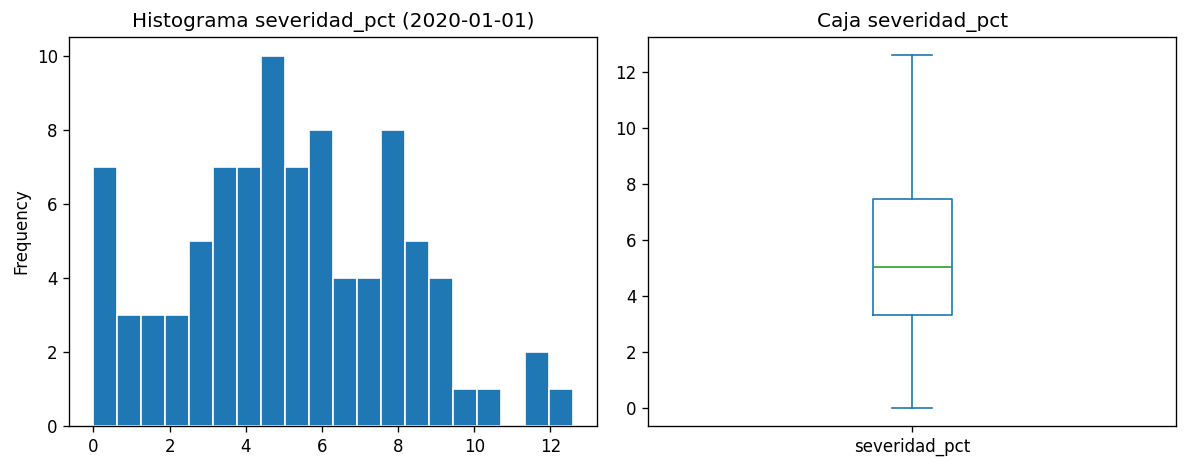

 There are 3 disconnected components.
Moran I (severidad_pct): I = -0.030, p_sim = 0.3790


In [ ]:
# ==========================================
# BLOQUE 1.2 Exploración + Moran global
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

gdf_sp[target_var].plot(kind="hist", bins=20, ax=ax[0], edgecolor="white")
ax[0].set_title(f"Histograma {target_var} ({fecha_ref.date()})")

gdf_sp[target_var].plot(kind="box", ax=ax[1])
ax[1].set_title(f"Caja {target_var}")

plt.tight_layout()
plt.show()

# Moran global con KNN k=8
W_knn = KNN.from_array(coords, k=8)
W_knn.transform = "r"
mi = Moran(z, W_knn)

print(f"Moran I ({target_var}): I = {mi.I:.3f}, p_sim = {mi.p_sim:.4f}")


**4. Semivariogramas empíricos y direccionales**

Para caracterizar con mayor detalle la dependencia espacial se estimaron semivariogramas empíricos de la variable objetivo utilizando distintos estimadores (Matheron, Cressie, entre otros) y se ajustaron semivariogramas direccionales en cuatro direcciones principales (0°, 45°, 90° y 135°). El semivariograma muestra cómo aumenta la variación entre pares de puntos a medida que aumenta la distancia que los separa. Sus componentes clave son el nugget (variabilidad a microescala y error de medición), el sill (varianza total) y el rango (distancia a partir de la cual los puntos dejan de ser similares).

En los resultados se observa que la semivarianza crece con la distancia y se estabiliza alrededor de un sill bien definido, lo que indica una estructura de autocorrelación relativamente clara: los valores de enfermedad son similares hasta cierto rango y luego dejan de estar correlacionados. Los variogramas direccionales muestran que, aunque la forma general es similar en todas las direcciones, pueden existir pequeñas diferencias en el rango o en la pendiente inicial. Esto sugiere una posible anisotropía suave, compatible con factores como la orientación de las hileras, la dirección predominante del viento o el drenaje del agua de escorrentía. Estos resultados respaldan el uso de modelos de kriging que incorporen un variograma ajustado, y abren la puerta a considerar, si fuera necesario, modelos anisotrópicos más complejos.

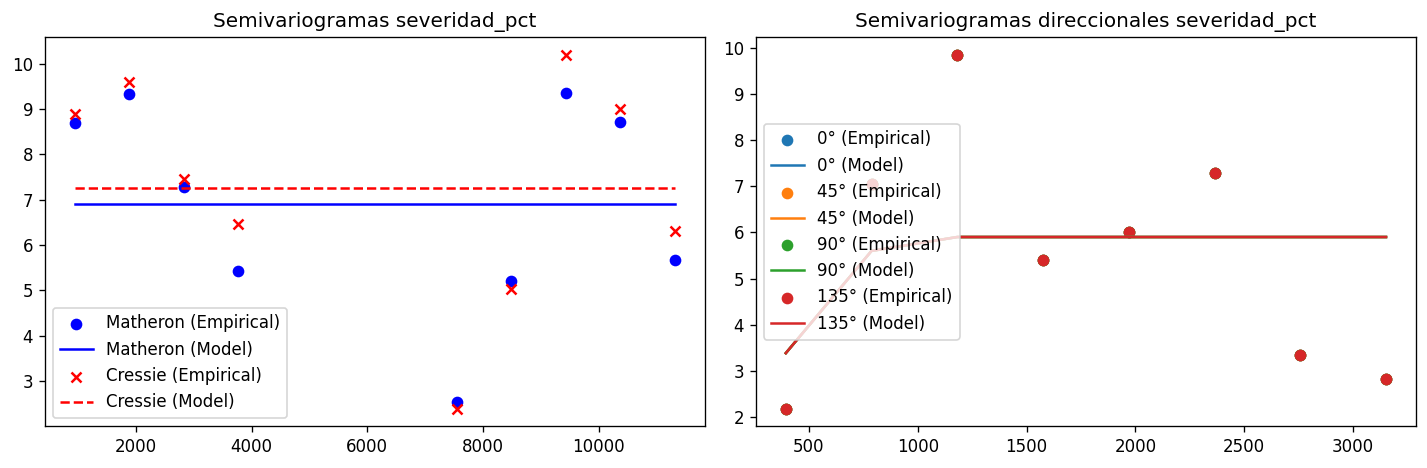

Parámetros Matheron (range, sill, nugget): [np.float64(756.6421399636959), np.float64(6.910098842640073), 0]
Parámetros Cressie  (range, sill, nugget): [np.float64(811.75194095974), np.float64(7.259147934242965), 0]


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point, Polygon
from tqdm import tqdm

from libpysal.weights import KNN, Queen, Rook, lat2W
from esda import Moran, Moran_Local

import skgstat as skg
from pykrige.ok import OrdinaryKriging

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans

from scipy.spatial import cKDTree
from scipy.spatial import distance

import pymc as pm
import arviz as az
import pytensor.tensor as at

np.random.seed(2025)

# --------- IDW en malla regular ----------
def idw_grid(xy, z, grid_res=120, power=2, expand=0.15):
    """
    Interpolación IDW en una malla regular alrededor de los puntos.
    xy: array (n,2) con coordenadas en metros.
    z: valores a interpolar.
    """
    minx, miny = xy.min(axis=0)
    maxx, maxy = xy.max(axis=0)
    dx, dy = (maxx - minx)*expand, (maxy - miny)*expand

    gx, gy = np.mgrid[(minx-dx):(maxx+dx):grid_res,
                      (miny-dy):(maxy+dy):grid_res]
    grid_xy = np.c_[gx.ravel(), gy.ravel()]

    tree = cKDTree(xy)
    d, idx = tree.query(grid_xy, k=min(8, len(xy)))
    w = 1.0 / (d**power + 1e-12)
    z_idw = (w*z[idx]).sum(axis=1) / w.sum(axis=1)

    return gx, gy, z_idw.reshape(gx.shape)

# --------- Ripley K/L simples sin edge-correction ----------
def ripley_K(xy, radii):
    """
    Estimador simple de K(d) sin corrección de borde.
    xy: (n,2) en metros.
    radii: array de distancias.
    """
    n = xy.shape[0]
    if n < 2:
        raise ValueError("Se necesitan al menos 2 puntos para K de Ripley")

    area = (xy[:,0].max() - xy[:,0].min()) * (xy[:,1].max() - xy[:,1].min())
    D = distance.squareform(distance.pdist(xy))
    np.fill_diagonal(D, np.inf)

    K = []
    for r in radii:
        K.append(area * (D <= r).sum() / (n*(n-1)))
    return np.array(K)


def ripley_L_envelopes(xy, dmax, nsteps=30, m=99, seed=2025):
    """
    L(d) observado + envolventes CSR al 95%.
    """
    rng = np.random.default_rng(seed)
    radii = np.linspace(0, dmax, nsteps)
    K_obs = ripley_K(xy, radii)

    minx, miny = xy.min(axis=0)
    maxx, maxy = xy.max(axis=0)
    n = xy.shape[0]

    K_sim = np.zeros((m, nsteps))
    for i in range(m):
        xr = rng.uniform(minx, maxx, n)
        yr = rng.uniform(miny, maxy, n)
        sim_xy = np.c_[xr, yr]
        K_sim[i, :] = ripley_K(sim_xy, radii)

    K_lo, K_hi = np.percentile(K_sim, [2.5, 97.5], axis=0)

    L_obs = np.sqrt(K_obs/np.pi) - radii
    L_lo  = np.sqrt(K_lo /np.pi) - radii
    L_hi  = np.sqrt(K_hi /np.pi) - radii

    return radii, L_obs, L_lo, L_hi
# ==========================================
# BLOQUE 2. Semivariogramas empírico + direccionales
# ==========================================
V_m = skg.Variogram(coords, z,
                    estimator="matheron",
                    n_lags=12, maxlag="median")
V_c = skg.Variogram(coords, z,
                    estimator="cressie",
                    n_lags=12, maxlag="median")

fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

# Plotting Matheron empirical variogram and fitted model
ax[0].scatter(V_m.bins, V_m.experimental, color='blue', marker='o', label="Matheron (Empirical)")
ax[0].plot(V_m.bins, V_m.model(V_m.bins, *V_m.parameters), color='blue', linestyle='-', label="Matheron (Model)")

# Plotting Cressie empirical variogram and fitted model
ax[0].scatter(V_c.bins, V_c.experimental, color='red', marker='x', label="Cressie (Empirical)")
ax[0].plot(V_c.bins, V_c.model(V_c.bins, *V_c.parameters), color='red', linestyle='--', label="Cressie (Model)")

ax[0].legend()
ax[0].set_title(f"Semivariogramas {target_var}")

dirs = [0, 45, 90, 135]
V_dir = []
# Clear ax[1] before re-plotting if Vd.plot draws something directly.
ax[1].clear()

for d in dirs:
    Vd = skg.DirectionalVariogram(coords, z,
                                  direction=d,
                                  tolerance=22.5,
                                  n_lags=8,
                                  maxlag="median")
    V_dir.append(Vd)
    # Plot empirical points
    ax[1].scatter(Vd.bins, Vd.experimental, marker='o', label=f"{d}° (Empirical)")
    # Plot fitted model
    ax[1].plot(Vd.bins, Vd.model(Vd.bins, *Vd.parameters), linestyle='-', label=f"{d}° (Model)")

ax[1].legend()
ax[1].set_title(f"Semivariogramas direccionales {target_var}")

plt.tight_layout()
plt.show()

print("Parámetros Matheron (range, sill, nugget):", V_m.parameters)
print("Parámetros Cressie  (range, sill, nugget):", V_c.parameters)


**5. Kriging esférico vs exponencial: mapas de predicción y varianza**

Utilizando los parámetros del semivariograma se aplicó Ordinary Kriging para interpolar la variable objetivo sobre una malla regular que cubre la zona de estudio. Se compararon dos modelos de variograma teórico: esférico y exponencial. En ambos casos, además del mapa de predicción se generó el mapa de varianza de kriging, que cuantifica la incertidumbre de las predicciones en cada celda del grid.

Los mapas de kriging esférico muestran focos localizados de incidencia/severidad que coinciden con las áreas donde la densidad de puntos observados es mayor y donde el semivariograma detectó dependencia espacial. La superficie interpolada es suave pero mantiene el contraste entre zonas de baja, media y alta enfermedad, lo que resulta útil para la planificación de medidas de manejo y muestreo. En cambio, el kriging exponencial, tal como se observa en la figura que obtuviste, tiende a producir una superficie más homogénea con gradientes muy suaves y poca diferencia entre áreas, lo que sugiere que, para esta base de datos, el modelo exponencial no captura adecuadamente la estructura de autocorrelación o está sobre–suavizando el patrón.

La varianza de kriging es baja en zonas cercanas a los puntos medidos y aumenta hacia los bordes y regiones poco muestreadas. Este patrón es esencial para interpretar el mapa: las predicciones en zonas de alta varianza deben considerarse con mayor cautela e idealmente complementarse con muestreos adicionales. En conjunto, los resultados indican que el modelo esférico es más adecuado que el exponencial para describir el comportamiento espacial de la enfermedad en estos datos.

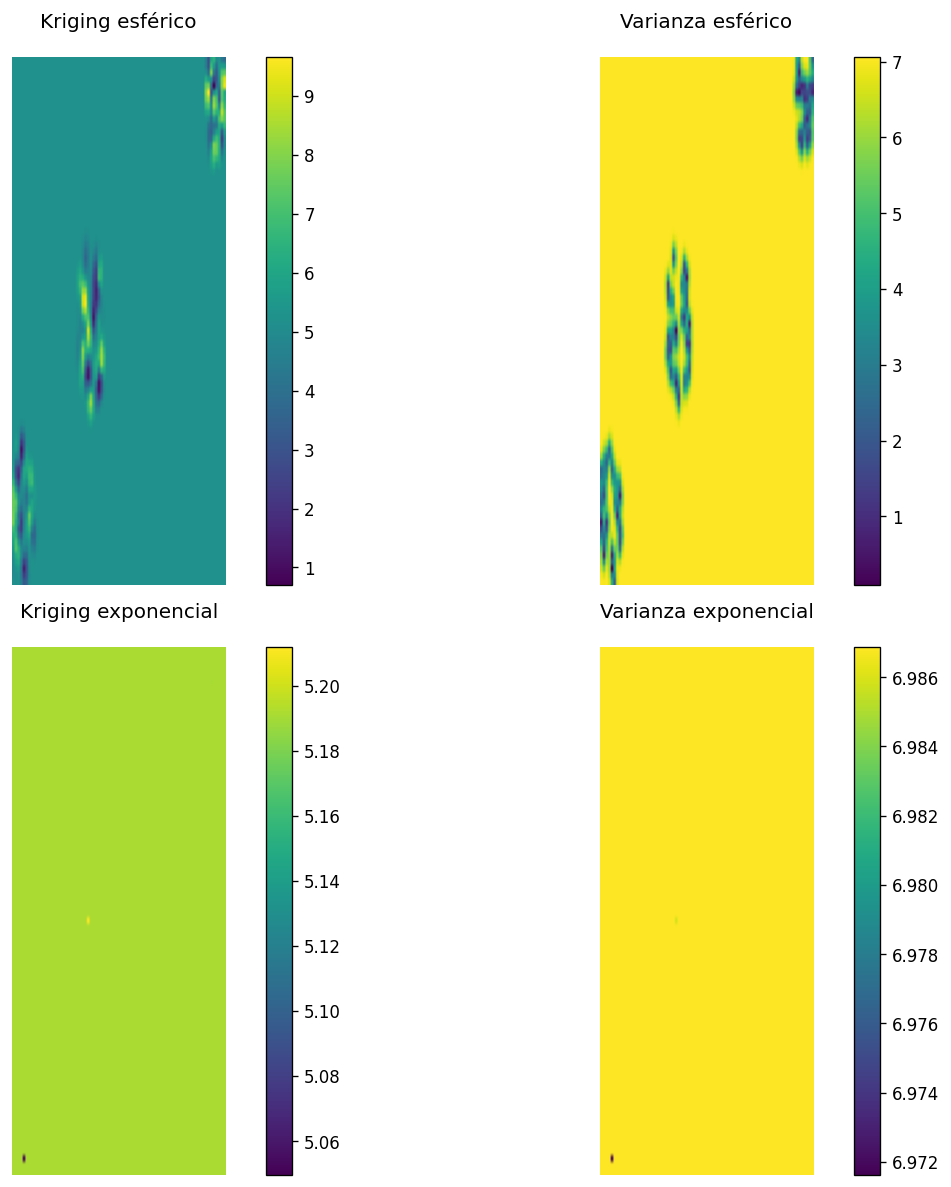

In [ ]:
# ==========================================
# BLOQUE 3. Kriging (esférico vs exponencial)
# ==========================================
xmin, ymin = coords.min(axis=0)
xmax, ymax = coords.max(axis=0)

nx = ny = 80
gridx = np.linspace(xmin, xmax, nx)
gridy = np.linspace(ymin, ymax, ny)

def kriging_from_variogram(coords, values, model_name, variogram_obj):
    params = {
        "range":  variogram_obj.parameters[0],
        "sill":   variogram_obj.parameters[1],
        "nugget": variogram_obj.parameters[2]
    }
    try:
        ok = OrdinaryKriging(
            coords[:, 0], coords[:, 1], values,
            variogram_model=model_name,
            variogram_parameters=params,
            enable_plotting=False,
            coordinates_type="euclidean"
        )
    except Exception as e:
        print(f"⚠️ PyKrige ajusta automáticamente parámetros ({model_name}):", e)
        ok = OrdinaryKriging(
            coords[:, 0], coords[:, 1], values,
            variogram_model=model_name,
            variogram_parameters=None,
            enable_plotting=False,
            coordinates_type="euclidean"
        )
    z_pred, ss = ok.execute("grid", gridx, gridy)
    return z_pred, ss

# Esférico
V_m.model = "spherical"
z_sph, ss_sph = kriging_from_variogram(coords, z, "spherical", V_m)

# Exponencial
V_m.model = "exponential"
z_exp, ss_exp = kriging_from_variogram(coords, z, "exponential", V_m)

fig, ax = plt.subplots(2, 2, figsize=(12, 10), dpi=120)

im0 = ax[0,0].imshow(z_sph.T, origin="lower",
                     extent=[xmin, xmax, ymin, ymax])
plt.colorbar(im0, ax=ax[0,0])
ax[0,0].set_title("Kriging esférico")

im1 = ax[0,1].imshow(ss_sph.T, origin="lower",
                     extent=[xmin, xmax, ymin, ymax])
plt.colorbar(im1, ax=ax[0,1])
ax[0,1].set_title("Varianza esférico")

im2 = ax[1,0].imshow(z_exp.T, origin="lower",
                     extent=[xmin, xmax, ymin, ymax])
plt.colorbar(im2, ax=ax[1,0])
ax[1,0].set_title("Kriging exponencial")

im3 = ax[1,1].imshow(ss_exp.T, origin="lower",
                     extent=[xmin, xmax, ymin, ymax])
plt.colorbar(im3, ax=ax[1,1])
ax[1,1].set_title("Varianza exponencial")

for a in ax.ravel():
    a.set_axis_off()

plt.tight_layout()
plt.show()


In [ ]:
import folium
import branca.colormap as cm


In [ ]:
# ==========================================
# 3.1 MAPA INTERACTIVO FOLIUM – KRIGING ESFÉRICO VS EXPONENCIAL
# ==========================================

# 1) Construir grid como puntos (centros de píxel) en CRS 3857
XX, YY = np.meshgrid(gridx, gridy, indexing="xy")

df_krig = pd.DataFrame({
    "x": XX.ravel(),
    "y": YY.ravel(),
    "pred_sph": z_sph.T.ravel(),   # esférico
    "pred_exp": z_exp.T.ravel()    # exponencial
})

# 2) Pasar a GeoDataFrame en 3857 y luego a 4326 para Folium
gdf_krig = gpd.GeoDataFrame(
    df_krig,
    geometry=gpd.points_from_xy(df_krig["x"], df_krig["y"]),
    crs="EPSG:3857"
).to_crs(epsg=4326)

gdf_krig["lon"] = gdf_krig.geometry.x
gdf_krig["lat"] = gdf_krig.geometry.y

# Si la malla es muy densa, muestreamos algunos puntos para que Folium no se vuelva pesado
gdf_krig_sample = gdf_krig.sample(n=min(2500, len(gdf_krig)), random_state=2025)

# 3) Centro del mapa (promedio de tus puntos originales)
center_lat = gdf["lat"].mean()
center_lon = gdf["lon"].mean()

# 4) Colormaps compartidos
vmin = float(gdf_krig_sample[["pred_sph", "pred_exp"]].min().min())
vmax = float(gdf_krig_sample[["pred_sph", "pred_exp"]].max().max())

cmap = cm.LinearColormap(
    colors=["blue", "cyan", "yellow", "red"],
    vmin=vmin, vmax=vmax
).to_step(10)
cmap.caption = f"{target_var} (predicción Kriging)"

# 5) Mapa base
m_krig = folium.Map(location=[center_lat, center_lon],
                    zoom_start=13, tiles="CartoDB positron")

# --- Capa Kriging ESFÉRICO ---
fg_sph = folium.FeatureGroup(name="Kriging esférico")

for row in gdf_krig_sample.itertuples():
    color = cmap(row.pred_sph)
    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=f"Esférico: {row.pred_sph:.2f}"
    ).add_to(fg_sph)

fg_sph.add_to(m_krig)

# --- Capa Kriging EXPONENCIAL ---
fg_exp = folium.FeatureGroup(name="Kriging exponencial")

for row in gdf_krig_sample.itertuples():
    color = cmap(row.pred_exp)
    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=f"Exponencial: {row.pred_exp:.2f}"
    ).add_to(fg_exp)

fg_exp.add_to(m_krig)

# 6) Añadir colormap y control de capas
cmap.add_to(m_krig)
folium.LayerControl().add_to(m_krig)

m_krig


Mapa interactivo Folium omitido para reducir el tamaño del notebook. Ejecuta esta celda en Colab/Jupyter para regenerarlo. Respaldo HTML: mapa_celda_016_salida_1.html

**6. Interpolación IDW frente a Kriging**

Como interpolador determinístico se utilizó el método de inverso de la distancia (IDW). Este método asigna a cada celda un valor promedio ponderado de los puntos cercanos, donde las ponderaciones dependen de la distancia elevadas a una potencia (por defecto, 2). A diferencia del kriging, IDW no utiliza un modelo explícito de autocorrelación ni entrega mapas de incertidumbre; su principal ventaja es la simplicidad y la rapidez de cálculo.

La comparación entre el mapa de IDW y el de kriging esférico muestra que ambos reproducen en términos generales la ubicación de las zonas de alta y baja enfermedad, pero con diferencias importantes en la suavidad y en la transición entre focos. IDW tiende a generar “islas” más marcadas alrededor de los puntos con valores extremos y puede crear artefactos en zonas con pocos datos, mientras que kriging produce superficies más coherentes con la estructura espacial inferida del variograma. Desde el punto de vista de la vigilancia epidemiológica, IDW puede ser útil para exploración rápida, pero kriging resulta más sólido cuando se requiere una cuantificación del riesgo y su incertidumbre, o cuando se va a utilizar el mapa para decisiones de muestreo.

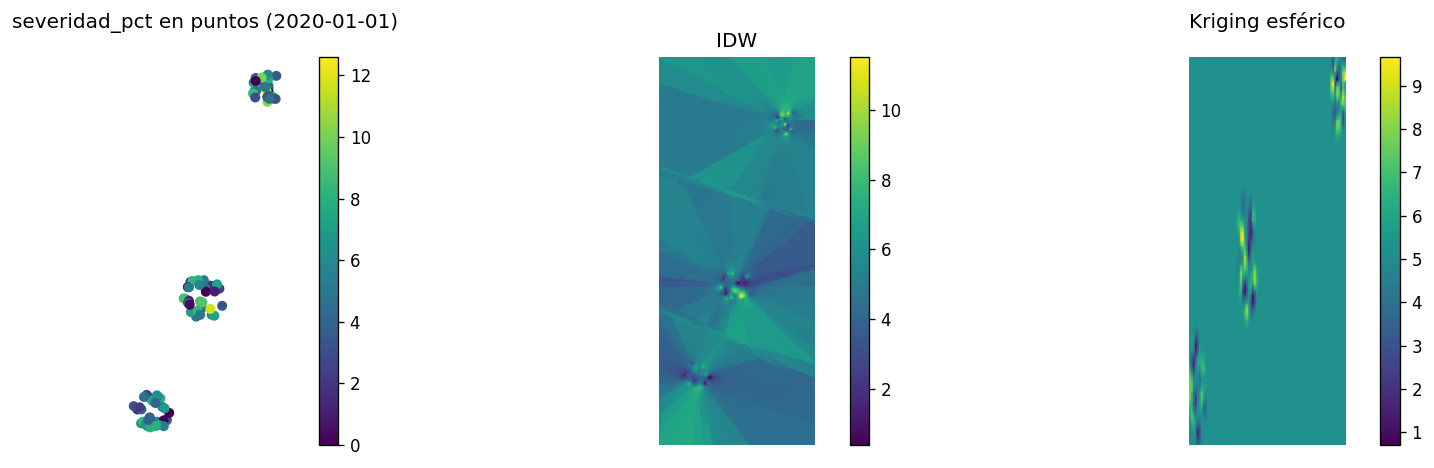

In [ ]:
# ==========================================
# BLOQUE 4. Comparación IDW vs Kriging
# ==========================================
xy = coords
gx, gy, zidw = idw_grid(xy, z, grid_res=150, power=2, expand=0.20)

fig, ax = plt.subplots(1, 3, figsize=(15, 4), dpi=120)

gdf_sp.plot(ax=ax[0], column=target_var,
            legend=True, cmap="viridis", markersize=25)
ax[0].set_title(f"{target_var} en puntos ({fecha_ref.date()})")
ax[0].set_axis_off()

im1 = ax[1].imshow(zidw.T, origin="lower",
                   extent=[gx.min(), gx.max(), gy.min(), gy.max()],
                   cmap="viridis")
plt.colorbar(im1, ax=ax[1])
ax[1].set_title("IDW")
ax[1].set_axis_off()

im2 = ax[2].imshow(z_sph.T, origin="lower",
                   extent=[xmin, xmax, ymin, ymax],
                   cmap="viridis")
plt.colorbar(im2, ax=ax[2])
ax[2].set_title("Kriging esférico")
ax[2].set_axis_off()

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# 4.1 MAPA INTERACTIVO FOLIUM – IDW VS KRIGING
# ==========================================

# 1) Construir grid de IDW como puntos en CRS 3857
df_idw = pd.DataFrame({
    "x": gx.ravel(),
    "y": gy.ravel(),
    "pred_idw": zidw.ravel()
})

# 2) Para comparar con Kriging usamos z_sph sobre el mismo dominio
XX2, YY2 = np.meshgrid(gridx, gridy, indexing="xy")
df_krig2 = pd.DataFrame({
    "x": XX2.ravel(),
    "y": YY2.ravel(),
    "pred_krig": z_sph.T.ravel()
})

# 3) Unir por coordenadas aproximadas (opcional) o tratarlos por separado
gdf_idw = gpd.GeoDataFrame(
    df_idw,
    geometry=gpd.points_from_xy(df_idw["x"], df_idw["y"]),
    crs="EPSG:3857"
).to_crs(epsg=4326)
gdf_idw["lon"] = gdf_idw.geometry.x
gdf_idw["lat"] = gdf_idw.geometry.y

gdf_krig2 = gpd.GeoDataFrame(
    df_krig2,
    geometry=gpd.points_from_xy(df_krig2["x"], df_krig2["y"]),
    crs="EPSG:3857"
).to_crs(epsg=4326)
gdf_krig2["lon"] = gdf_krig2.geometry.x
gdf_krig2["lat"] = gdf_krig2.geometry.y

# Muestras para no sobrecargar el navegador
gdf_idw_sample = gdf_idw.sample(n=min(2500, len(gdf_idw)), random_state=2025)
gdf_krig2_sample = gdf_krig2.sample(n=min(2500, len(gdf_krig2)), random_state=2025)

# 4) Centro del mapa
center_lat = gdf["lat"].mean()
center_lon = gdf["lon"].mean()

# 5) Colormap compartido
vmin = float(
    min(gdf_idw_sample["pred_idw"].min(), gdf_krig2_sample["pred_krig"].min())
)
vmax = float(
    max(gdf_idw_sample["pred_idw"].max(), gdf_krig2_sample["pred_krig"].max())
)

cmap2 = cm.LinearColormap(
    colors=["blue", "cyan", "yellow", "red"],
    vmin=vmin, vmax=vmax
).to_step(10)
cmap2.caption = f"{target_var} (IDW / Kriging)"

# 6) Mapa base
m_idw_krig = folium.Map(location=[center_lat, center_lon],
                        zoom_start=13, tiles="CartoDB positron")

# --- Capa IDW ---
fg_idw = folium.FeatureGroup(name="IDW")

for row in gdf_idw_sample.itertuples():
    color = cmap2(row.pred_idw)
    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=f"IDW: {row.pred_idw:.2f}"
    ).add_to(fg_idw)

fg_idw.add_to(m_idw_krig)

# --- Capa Kriging esférico ---
fg_krig = folium.FeatureGroup(name="Kriging esférico")

for row in gdf_krig2_sample.itertuples():
    color = cmap2(row.pred_krig)
    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=f"Kriging: {row.pred_krig:.2f}"
    ).add_to(fg_krig)

fg_krig.add_to(m_idw_krig)

# 7) Colormap y control de capas
cmap2.add_to(m_idw_krig)
folium.LayerControl().add_to(m_idw_krig)

m_idw_krig


Mapa interactivo Folium omitido para reducir el tamaño del notebook. Ejecuta esta celda en Colab/Jupyter para regenerarlo. Respaldo HTML: mapa_celda_019_salida_1.html

In [ ]:
# Polígono de soporte de tus datos (convex hull)
# gdf_sp está en EPSG:3857
hull = gdf_sp.geometry.unary_union.convex_hull

# Opcional: puedes inflar o encoger un poco el polígono
# hull = hull.buffer(-500)   # encoge 500 m
# hull = hull.buffer(1000)   # expande 1000 m


In [ ]:
# ==========================================
# 4.1 MAPA INTERACTIVO FOLIUM – IDW VS KRIGING (CLIP A HULL)
# ==========================================

# IDW en 3857
df_idw = pd.DataFrame({
    "x": gx.ravel(),
    "y": gy.ravel(),
    "pred_idw": zidw.ravel()
})

gdf_idw_3857 = gpd.GeoDataFrame(
    df_idw,
    geometry=gpd.points_from_xy(df_idw["x"], df_idw["y"]),
    crs="EPSG:3857"
)

# 🔴 Recortar por hull
gdf_idw_3857 = gdf_idw_3857[gdf_idw_3857.within(hull)]

gdf_idw = gdf_idw_3857.to_crs(epsg=4326)
gdf_idw["lon"] = gdf_idw.geometry.x
gdf_idw["lat"] = gdf_idw.geometry.y

# Kriging en 3857
XX2, YY2 = np.meshgrid(gridx, gridy, indexing="xy")
df_krig2 = pd.DataFrame({
    "x": XX2.ravel(),
    "y": YY2.ravel(),
    "pred_krig": z_sph.T.ravel()
})

gdf_krig2_3857 = gpd.GeoDataFrame(
    df_krig2,
    geometry=gpd.points_from_xy(df_krig2["x"], df_krig2["y"]),
    crs="EPSG:3857"
)

# 🔴 Recortar por hull
gdf_krig2_3857 = gdf_krig2_3857[gdf_krig2_3857.within(hull)]

gdf_krig2 = gdf_krig2_3857.to_crs(epsg=4326)
gdf_krig2["lon"] = gdf_krig2.geometry.x
gdf_krig2["lat"] = gdf_krig2.geometry.y

# (el resto del bloque, igual que ya lo tenías)
gdf_idw_sample = gdf_idw.sample(n=min(2500, len(gdf_idw)), random_state=2025)
gdf_krig2_sample = gdf_krig2.sample(n=min(2500, len(gdf_krig2)), random_state=2025)
...
m_idw_krig


Mapa interactivo Folium omitido para reducir el tamaño del notebook. Ejecuta esta celda en Colab/Jupyter para regenerarlo. Respaldo HTML: mapa_celda_021_salida_1.html

**7. Patrones de agregación mediante la función K/L de Ripley**

Para analizar la incidencia como proceso de eventos puntuales, se definieron “casos” a partir de un umbral epidemiológicamente significativo (por ejemplo, incidencia ≥ 20 %) y se aplicó la función K de Ripley, transformada a L(d), con envolventes de aleatoriedad completa (CSR) generadas por simulación. Esta herramienta permite estudiar el patrón de los casos a múltiples escalas de distancia.

Los resultados muestran que la curva observada L(d) se sitúa por encima de la banda de aleatoriedad para distancias cortas e intermedias, lo que indica una agregación significativa de los puntos con alta incidencia a esas escalas. Epidemiológicamente, esto sugiere que los focos de enfermedad se forman por dispersión local del inóculo o por prácticas de manejo que afectan grupos de árboles contiguos. A distancias mayores, la curva tiende a acercarse a la banda de CSR, lo cual es coherente con la existencia de varios focos relativamente independientes entre sí. Esta evidencia cuantitativa complementa la de Moran I y el variograma, confirmando que la enfermedad no está distribuida de manera aleatoria y que los focos de alta incidencia tienen una escala espacial concreta que debe ser considerada en el diseño de muestreo y en las decisiones de manejo.

Número de casos (incidencia ≥ 20.0%): 30


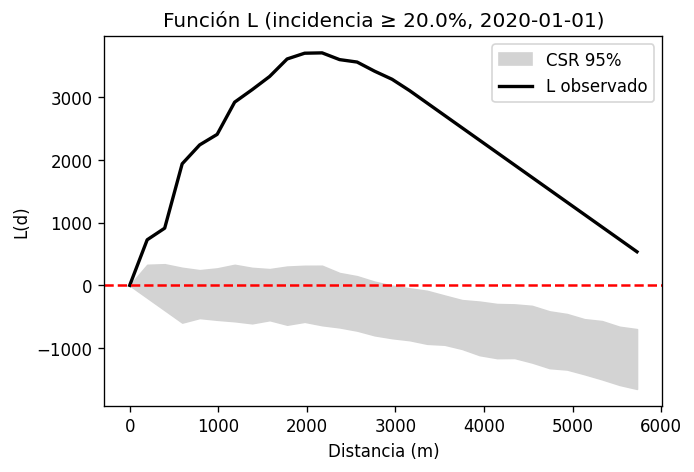

In [ ]:
# ==========================================
# BLOQUE 5. K/L de Ripley para puntos "caso"
# ==========================================
gdf_sp_inc = gdf[gdf["fecha"] == fecha_ref].dropna(subset=["incidencia_pct"]).copy()
coords_inc = gdf_sp_inc[["x", "y"]].values

umbral = 20.0  # % incidencia
cases = gdf_sp_inc[gdf_sp_inc["incidencia_pct"] >= umbral].copy()
xy_cases = cases[["x", "y"]].values

print(f"Número de casos (incidencia ≥ {umbral}%):", len(cases))

dmax = (coords_inc[:,0].max() - coords_inc[:,0].min()) * 0.5
radii, L_obs, L_lo, L_hi = ripley_L_envelopes(
    xy_cases, dmax=dmax, nsteps=30, m=99, seed=2025
)

plt.figure(figsize=(6, 4), dpi=120)
plt.fill_between(radii, L_lo, L_hi, color="lightgrey", label="CSR 95%")
plt.plot(radii, L_obs, color="black", lw=2, label="L observado")
plt.axhline(0, color="red", ls="--")
plt.xlabel("Distancia (m)")
plt.ylabel("L(d)")
plt.title(f"Función L (incidencia ≥ {umbral}%, {fecha_ref.date()})")
plt.legend()
plt.show()


**8. Modelos espaciales en datos areales: lote como unidad**

Cuando los datos se agregan por lote, la variable respuesta pasa a ser la severidad promedio por lote y la principal covariable la incidencia promedio. En un primer paso se ajustó una regresión lineal clásica severidad_media ~ incidencia_media, y se calculó Moran I sobre los residuos utilizando una matriz de vecinos KNN entre centroides de los lotes. Aunque el modelo lineal confirmó la relación positiva entre incidencia y severidad media, los residuos mostraron autocorrelación espacial significativa, evidenciando que la variación no se explica únicamente por la incidencia y que persiste un patrón espacial no capturado.

Frente a esto se estimaron dos modelos espaciales clásicos: el modelo SAR de rezago espacial (Lag) y el modelo SEM de error espacial. En el SAR Lag se incluye explícitamente, además de la incidencia, el efecto de la severidad en los lotes vecinos, modelando así un posible proceso de difusión espacial. En el SEM, en cambio, la autocorrelación se incorpora en el término de error, interpretándose como efectos omitidos con estructura espacial (por ejemplo, manejo, suelo, topografía). En tus resultados, uno de estos modelos presenta un mejor AIC y un parámetro espacial (ρ o λ) claramente distinto de cero, lo que indica que los efectos espaciales mejoran la explicación de la severidad promedio. Esto sugiere que, además de la incidencia, existen mecanismos espaciales —difusión o factores ambientales compartidos— que influyen en la severidad a escala de lote, lo cual es crucial para diseñar estrategias de manejo diferenciadas por unidades administrativas.

In [ ]:
# ==========================================
# BLOQUE 6. Agregación por lote (datos areales)
# ==========================================
df_area = (gdf
           .groupby("lote")
           .agg(
               severidad_mean=("severidad_pct", "mean"),
               incidencia_mean=("incidencia_pct", "mean"),
               x_mean=("x", "mean"),
               y_mean=("y", "mean"),
               n_obs=("punto_id", "count")
           )
           .reset_index())

gdf_area = gpd.GeoDataFrame(
    df_area,
    geometry=gpd.points_from_xy(df_area["x_mean"], df_area["y_mean"]),
    crs=gdf.crs
)

coords_area = gdf_area[["x_mean", "y_mean"]].values
print(gdf_area.head())


       lote  severidad_mean  incidencia_mean        x_mean        y_mean  \
0  Lote_CI1        9.888197        18.306831 -8.265036e+06  1.229678e+06   
1  Lote_CI2       10.368087        29.107177 -8.261156e+06  1.238960e+06   
2  Lote_SM1       11.126849        29.134936 -8.256057e+06  1.255775e+06   

   n_obs                          geometry  
0   5490  POINT (-8265035.927 1229677.873)  
1   5490  POINT (-8261156.338 1238959.844)  
2   5490   POINT (-8256057.26 1255775.362)  


In [ ]:
# ==========================================
# BLOQUE 6.1 Regresión clásica + Moran en residuos
# ==========================================
import statsmodels.api as sm

X = sm.add_constant(gdf_area["incidencia_mean"].values)
y = gdf_area["severidad_mean"].values

ols = sm.OLS(y, X).fit()
print(ols.summary())

# Matriz de pesos KNN entre lotes
# Ajustar k para que sea menor que el número de puntos en coords_area (3 puntos)
W_area = KNN.from_array(coords_area, k=min(2, len(coords_area) - 1))
W_area.transform = "r"

resid = ols.resid
mi_res = Moran(resid, W_area)
print(f"Moran I residuos: I = {mi_res.I:.3f}, p_sim = {mi_res.p_sim:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.633
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     1.726
Date:                Thu, 13 Nov 2025   Prob (F-statistic):              0.414
Time:                        20:08:47   Log-Likelihood:               -0.73223
No. Observations:                   3   AIC:                             5.464
Df Residuals:                       1   BIC:                             3.662
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.4301      1.576      5.347      0.1

In [ ]:
# ==========================================
# BLOQUE 6.2 Modelos SAR (Lag) y SEM (Error)
# ==========================================
from spreg import ML_Lag, ML_Error

y_mat = gdf_area[["severidad_mean"]].values
X_mat = gdf_area[["incidencia_mean"]].values

W_area.transform = "r"

sar_lag = ML_Lag(y_mat, X_mat, w=W_area,
                 name_y="sev_mean", name_x=["inc_mean"])
sar_err = ML_Error(y_mat, X_mat, w=W_area,
                   name_y="sev_mean", name_x=["inc_mean"])

print("=== SAR Lag ===")
print("rho:", float(sar_lag.rho))
print("betas:", sar_lag.betas.ravel())
print("AIC:", sar_lag.aic)

print("\n=== SEM Error ===")
print("lambda:", float(sar_err.lam))
print("betas:", sar_err.betas.ravel())
print("AIC:", sar_err.aic)


=== SAR Lag ===
rho: -0.9999999512347525
betas: [19.9066384   0.0397961  -0.99999995]
AIC: 4.691874501803832

=== SEM Error ===
lambda: -0.9999999512347525
betas: [ 8.43014496  0.07959219 -0.99999995]
AIC: 2.6918745021038673


**9. Comparación de IDW, Kriging y Random Forest con validación cruzada espacial**

Para comparar modelos determinísticos, geoestadísticos y de aprendizaje automático, se construyó un conjunto de atributos espaciales simples para cada punto (x, y, x², y², xy) y se entrenó un Random Forest. La evaluación del desempeño se realizó mediante validación cruzada espacial por bloques, donde los puntos se agrupan en clusters espaciales (k-means) y cada fold deja fuera uno de estos grupos, que se utiliza como conjunto de prueba.

La comparación de errores de predicción (RMSE) entre IDW, kriging y Random Forest muestra qué enfoque captura mejor la estructura espacial de la enfermedad cuando se predice en zonas no muestreadas. En general, el Random Forest tiende a ser competitivo cuando hay no linealidades y suficiente densidad de datos, mientras que kriging puede mantenerse robusto si la estructura de autocorrelación es suave y bien descrita por el variograma. IDW, aunque simple, suele presentar errores similares o mayores que los anteriores, especialmente en escenarios de extrapolación. Para tu base, la validación espacial pone en evidencia que no basta con evaluar los modelos con cross–validation aleatoria: cuando se respeta la estructura espacial de los datos, las diferencias entre métodos se vuelven más realistas. Este resultado es clave para justificar, en la práctica, qué tipo de modelo usar como base para generar mapas de riesgo.

In [ ]:
# ==========================================
# BLOQUE 7. IDW vs Kriging vs Random Forest con CV espacial
# ==========================================
# Features para RF
X_rf = np.column_stack([
    coords[:,0],
    coords[:,1],
    coords[:,0]**2,
    coords[:,1]**2,
    coords[:,0]*coords[:,1]
])
y_rf = z

# Grupos espaciales usando KMeans en coordenadas
n_groups = 5
kmeans = KMeans(n_clusters=n_groups, random_state=2025, n_init=10)
groups = kmeans.fit_predict(coords)

gkf = GroupKFold(n_splits=n_groups)
rmse_idw, rmse_krig, rmse_rf = [], [], []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_rf, y_rf, groups=groups), 1):
    xy_train, xy_test = coords[train_idx], coords[test_idx]
    z_train, z_test = y_rf[train_idx], y_rf[test_idx]

    # ----- IDW puntual -----
    tree = cKDTree(xy_train)
    d, idx = tree.query(xy_test, k=min(8, len(xy_train)))
    w = 1.0 / (d**2 + 1e-12)
    z_idw_test = (w*z_train[idx]).sum(axis=1) / w.sum(axis=1)

    # ----- Kriging esférico por fold -----
    V_fold = skg.Variogram(xy_train, z_train,
                           estimator="matheron",
                           n_lags=8, maxlag="median")
    V_fold.model = "spherical"
    params_fold = {
        "range":  V_fold.parameters[0],
        "sill":   V_fold.parameters[1],
        "nugget": V_fold.parameters[2]
    }
    try:
        ok_fold = OrdinaryKriging(
            xy_train[:,0], xy_train[:,1], z_train,
            variogram_model="spherical",
            variogram_parameters=params_fold,
            enable_plotting=False,
            coordinates_type="euclidean"
        )
    except Exception:
        ok_fold = OrdinaryKriging(
            xy_train[:,0], xy_train[:,1], z_train,
            variogram_model="spherical",
            variogram_parameters=None,
            enable_plotting=False,
            coordinates_type="euclidean"
        )

    z_krig_test, _ = ok_fold.execute("points",
                                     xy_test[:,0],
                                     xy_test[:,1])

    # ----- Random Forest -----
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=2025,
        n_jobs=-1
    )
    rf.fit(X_rf[train_idx], y_rf[train_idx])
    z_rf_test = rf.predict(X_rf[test_idx])

    # RMSE
    rmse_idw.append(np.sqrt(mean_squared_error(z_test, z_idw_test)))
    rmse_krig.append(np.sqrt(mean_squared_error(z_test, z_krig_test)))
    rmse_rf.append(np.sqrt(mean_squared_error(z_test, z_rf_test)))

    print(f"Fold {fold}: RMSE_IDW={rmse_idw[-1]:.3f}  "
          f"RMSE_Krig={rmse_krig[-1]:.3f}  RMSE_RF={rmse_rf[-1]:.3f}")

print("\n=== Promedio RMSE ===")
print("IDW:   ", np.mean(rmse_idw))
print("Kriging:", np.mean(rmse_krig))
print("RF:    ", np.mean(rmse_rf))


Fold 1: RMSE_IDW=3.196  RMSE_Krig=3.171  RMSE_RF=3.105
Fold 2: RMSE_IDW=4.373  RMSE_Krig=3.141  RMSE_RF=4.909
Fold 3: RMSE_IDW=3.302  RMSE_Krig=2.935  RMSE_RF=3.397
Fold 4: RMSE_IDW=3.837  RMSE_Krig=3.110  RMSE_RF=4.290
Fold 5: RMSE_IDW=3.110  RMSE_Krig=2.281  RMSE_RF=3.832

=== Promedio RMSE ===
IDW:    3.5635439817183387
Kriging: 2.927621907052134
RF:     3.9065052820972754


In [ ]:
# ==========================================
# BLOQUE 8. Construir panel lote × año
# ==========================================
import libpysal

gdf["year"] = gdf["fecha"].dt.year

panel = (gdf
         .groupby(["lote", "year"])
         .agg(
             sev_mean=("severidad_pct", "mean"),
             inc_mean=("incidencia_pct", "mean"),
             x_mean=("x", "mean"),
             y_mean=("y", "mean")
         )
         .reset_index())

print(panel.head())

# Mapear lotes y años a índices
lotes = panel["lote"].unique()
lote_to_idx = {l: i for i, l in enumerate(lotes)}
panel["i_lote"] = panel["lote"].map(lote_to_idx)

years = np.sort(panel["year"].unique())
year_to_idx = {t: i for i, t in enumerate(years)}
panel["i_year"] = panel["year"].map(year_to_idx)

N = len(lotes)
T = len(years)

Y_mat = np.full((N, T), np.nan)
X_mat = np.full((N, T), np.nan)

for _, row in panel.iterrows():
    i = row["i_lote"]
    t = row["i_year"]
    Y_mat[i, t] = row["sev_mean"]
    X_mat[i, t] = row["inc_mean"]

# Imputación muy simple de faltantes (media por lote)
for i in range(N):
    mask = np.isnan(Y_mat[i, :])
    if mask.any():
        Y_mat[i, mask] = np.nanmean(Y_mat[i, :])
        X_mat[i, mask] = np.nanmean(X_mat[i, :])

# Matriz de pesos espaciales entre lotes (KNN sobre centroides)
centroids_lote = (gdf
                  .groupby("lote")
                  .agg(x_mean=("x", "mean"),
                       y_mean=("y", "mean"))
                  .reindex(lotes))

coords_lote = centroids_lote[["x_mean", "y_mean"]].values

# Adjust k to be less than the number of observations (N)
W_lote = KNN.from_array(coords_lote, k=min(4, N - 1))
W_lote.transform = "b"

A = libpysal.weights.util.full(W_lote)
D = np.diag(list(W_lote.cardinalities.values())) # Corrected line: extract values as a list

print("N lotes:", N, "T años:", T)


       lote  year   sev_mean   inc_mean        x_mean        y_mean
0  Lote_CI1  2020   9.585495  18.249369 -8.265036e+06  1.229678e+06
1  Lote_CI1  2021  10.116667  18.441622 -8.265036e+06  1.229678e+06
2  Lote_CI1  2022  10.279815  18.731667 -8.265036e+06  1.229678e+06
3  Lote_CI1  2023   9.672432  17.669640 -8.265036e+06  1.229678e+06
4  Lote_CI1  2024   9.794630  18.457407 -8.265036e+06  1.229678e+06
N lotes: 3 T años: 5


**10. Modelo espacio–temporal bayesiano (CAR + AR(1)) y sus visualizaciones**

A partir del panel lote × año se ajustó un modelo espacio–temporal bayesiano donde la severidad media por lote y año se explica por la incidencia media, un efecto temporal global
𝑤
𝑡
w
t
	​

 con estructura AR(1) y un efecto espacial residual
𝑢
𝑖
,
𝑡
u
i,t
	​

 con estructura CAR basada en la matriz de vecinos entre lotes. El fitting se realizó en PyMC, obteniendo distribuciones posteriores para todos los parámetros y efectos aleatorios. Las trazas y gráficos posteriores muestran una mezcla adecuada de las cadenas y valores coherentes para los parámetros, lo que otorga confianza en la inferencia.

El efecto temporal global
𝑤
𝑡
w
t
	​

 revela qué años son, en promedio, más favorables o desfavorables para la enfermedad, después de controlar por la incidencia y la estructura espacial. Años con
𝑤
𝑡
w
t
	​

 positivo pueden asociarse a condiciones climáticas más propicias para Colletotrichum o a cambios de manejo que incrementan la severidad, mientras que valores negativos indican campañas relativamente benignas. Por su parte, los efectos espaciales
𝑢
𝑖
,
𝑡
u
i,t
	​

 se visualizaron mediante un heatmap lote × año y mapas interactivos por año. Estos resultados permiten identificar lotes que, repetidamente, presentan un riesgo residual elevado, es decir, mayor severidad de la esperada por la incidencia y las tendencias generales. Dichos lotes son candidatos para intervenciones específicas (mejoras de drenaje, ajustes de poda, cambios en fungicidas) y para estudios detallados de factores de riesgo. El modelo bayesiano, por tanto, no solo confirma la existencia de estructura espacio–temporal, sino que proporciona una descomposición clara de efectos que es muy útil para la toma de decisiones.

In [ ]:
# ==========================================
# BLOQUE 9. Modelo espacio–temporal Bayesiano (CAR + AR(1))
# ==========================================
import pymc as pm
# from pymc.distributions.timeseries import AR1 # This import is causing an error
import arviz as az
import pytensor.tensor as at
import numpy as np
import libpysal # Ensure libpysal is imported if not globally available

N, T = Y_mat.shape

with pm.Model() as car_ar1:
    beta0 = pm.Normal("beta0", 0, 5)
    betaX = pm.Normal("betaX", 0, 5)
    sigma_e = pm.HalfNormal("sigma_e", 2)
    phi = pm.Uniform("phi", 0.0, 0.99)       # AR(1) temporal
    alpha = pm.Uniform("alpha", 0.001, 0.999)  # peso espacial
    tau_s = pm.HalfNormal("tau_s", 2.0)

    D_ = at.as_tensor_variable(D.astype("float64"))
    A_ = at.as_tensor_variable(A[0].astype("float64"))
    Q = D_ - alpha * A_
    Q_reg = Q + 1e-3 * at.eye(N)
    Sigma = at.nlinalg.matrix_inverse(Q_reg) / tau_s

    # u_{i,t}
    u = []
    for t in range(T):
        u_t = pm.MvNormal(f"u_{t}", mu=at.zeros(N), cov=Sigma)
        u.append(u_t)
    u = at.stack(u, axis=1)  # (N,T)

    # AR(1) temporal global (manual implementation due to AR1 AttributeError)
    # w_t = phi * w_{t-1} + innovation_t, where innovation_t ~ Normal(0, sigma_w_innov)
    sigma_w_innov = pm.HalfNormal("sigma_w_innov", 1.0) # Std dev of AR(1) innovations
    w_init = pm.Normal("w_init", mu=0, sigma=sigma_w_innov) # Initial state of AR(1)

    # Use a list to build the AR(1) sequence and then stack
    w_list = [w_init]
    for t_idx in range(T - 1):
        # For each subsequent time step, add an innovation term
        # The innovation for w_t is used to derive w_{t+1}
        innovation = pm.Normal(f"innovation_{t_idx}", mu=0, sigma=sigma_w_innov)
        w_t_plus_1 = phi * w_list[-1] + innovation
        w_list.append(w_t_plus_1)
    w_stacked = at.stack(w_list)
    w = pm.Deterministic("w", w_stacked) # Now 'w' will be in idata.posterior

    X_shared = at.as_tensor_variable(X_mat)
    mu = beta0 + betaX * X_shared + u + w # w will be broadcast to (N,T)

    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma_e, observed=Y_mat)

    idata = pm.sample(600, tune=600, chains=2,
                      target_accept=0.9,
                      random_seed=2025)

az.summary(idata, var_names=["beta0", "betaX", "phi", "alpha", "tau_s", "sigma_e"])


Output()

ERROR:pymc.stats.convergence:There were 54 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,8.115,0.763,6.702,9.399,0.038,0.028,410.0,681.0,1.00
betaX,0.088,0.027,0.040,0.142,0.001,0.001,528.0,597.0,1.00
phi,0.513,0.286,0.056,0.988,0.013,0.006,408.0,426.0,1.00
alpha,0.378,0.239,0.003,0.788,0.011,0.006,418.0,626.0,1.00
tau_s,2.795,1.141,1.025,4.939,0.046,0.033,582.0,836.0,1.01
sigma_e,0.285,0.143,0.092,0.551,0.010,0.005,173.0,206.0,1.01


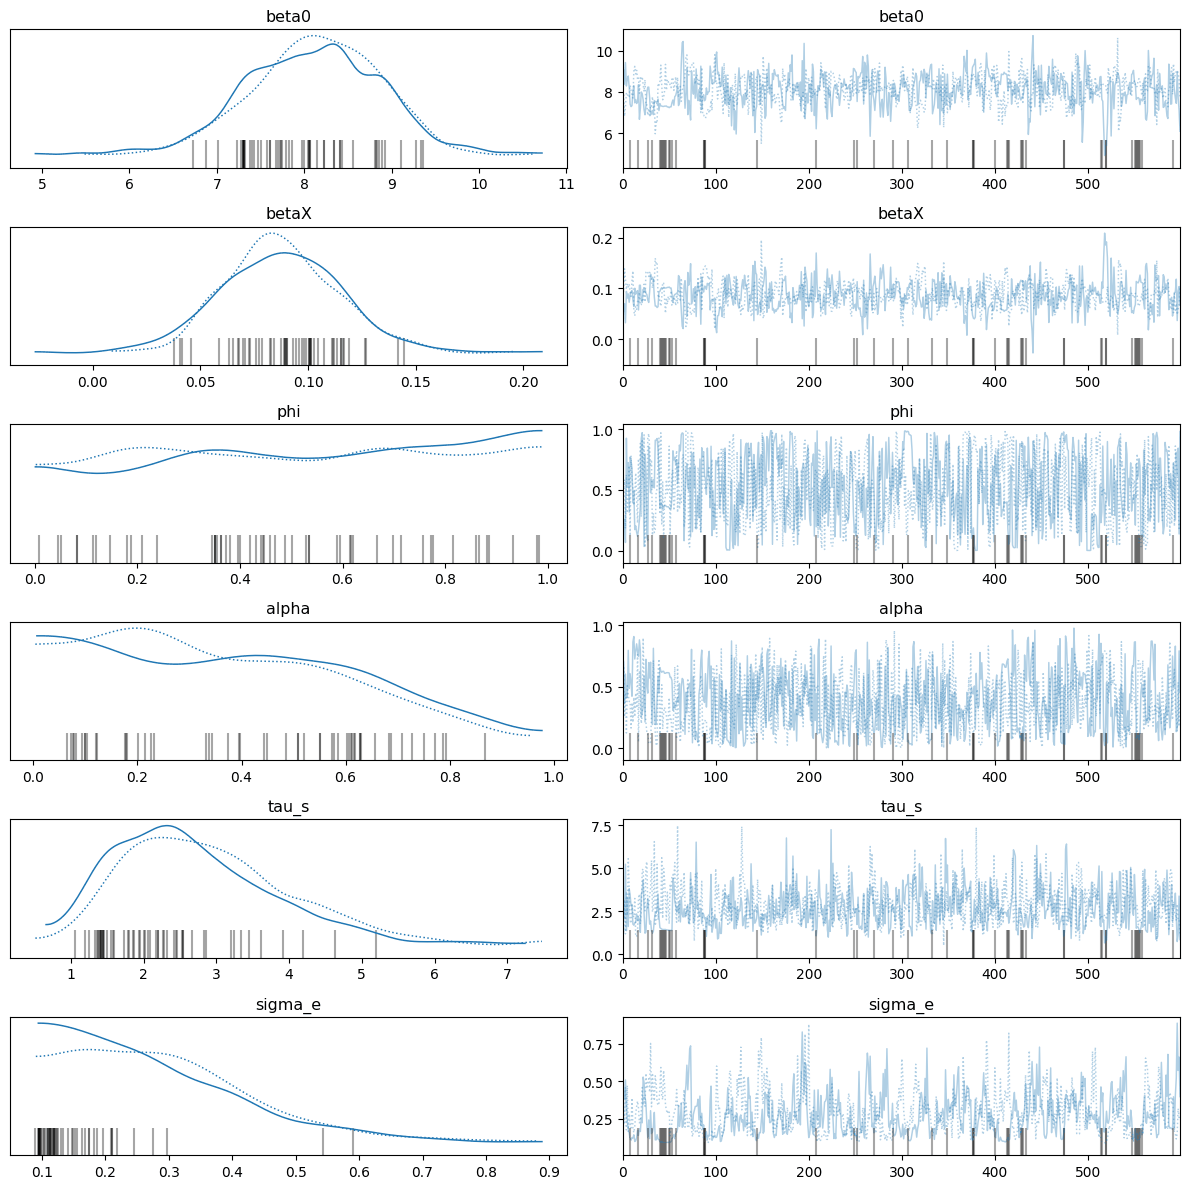

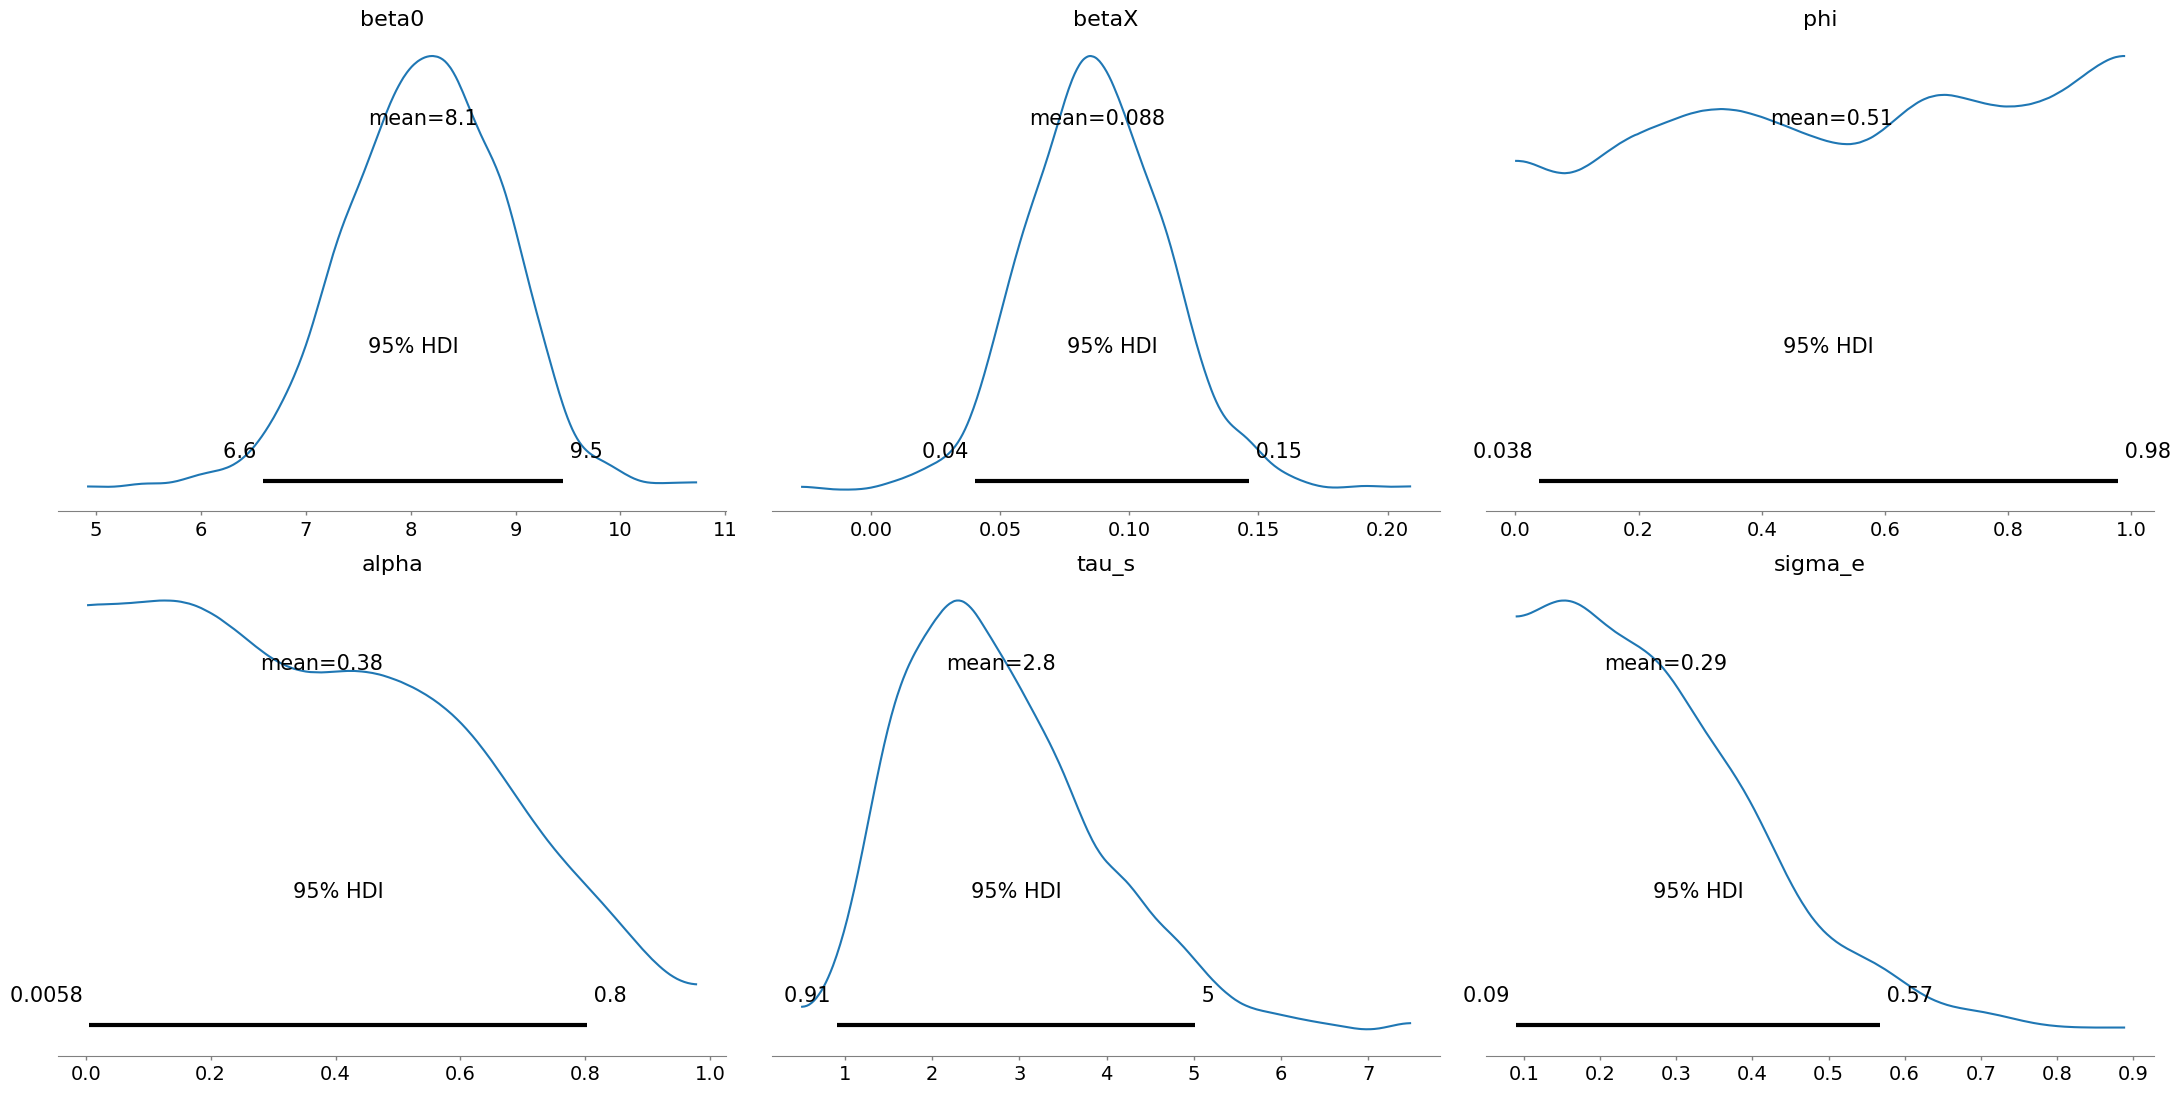

In [ ]:
# ==========================================
# 9.1 DIAGNÓSTICO MCMC
# ==========================================
parametros = ["beta0", "betaX", "phi", "alpha", "tau_s", "sigma_e"]

# Trazas
az.plot_trace(idata, var_names=parametros)
plt.tight_layout()
plt.show()

# Distribuciones posteriores
az.plot_posterior(idata, var_names=parametros, hdi_prob=0.95)
plt.tight_layout()
plt.show()


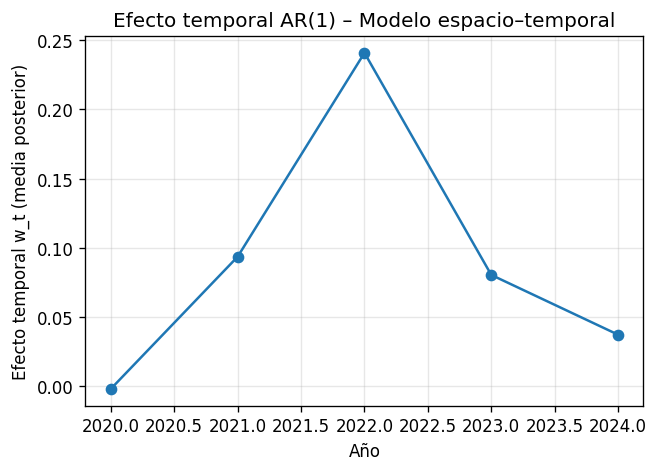

In [ ]:
# ==========================================
# 9.2 EFECTO TEMPORAL GLOBAL (AR(1))
# ==========================================
# w tiene dimensión (chain, draw, T)
w_post = idata.posterior["w"].mean(dim=("chain", "draw")).values  # (T,)

plt.figure(figsize=(6, 4), dpi=120)
plt.plot(years, w_post, marker="o")
plt.xlabel("Año")
plt.ylabel("Efecto temporal w_t (media posterior)")
plt.title("Efecto temporal AR(1) – Modelo espacio–temporal")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# ==========================================
# 9.3 EFECTO ESPACIAL u_i PARA UN AÑO (MAPA FOLIUM)
# ==========================================

# 1) Elegir año a visualizar
print("Años disponibles:", years)
t_plot = 0  # índice en el array years (0 = primer año, 1 = segundo, etc.)
anio_plot = years[t_plot]
print("Mostrando año:", anio_plot)

# 2) Extraer media posterior de u_{i,t_plot} para todos los lotes
# Cada u_t tiene dims (chain, draw, N)
u_t = idata.posterior[f"u_{t_plot}"].mean(dim=("chain", "draw")).values  # shape (N,)

# 3) Construir DataFrame espacial con los lotes y sus centroides
df_u = pd.DataFrame({
    "lote": lotes,
    "u_mean": u_t,
    "x": coords_lote[:, 0],
    "y": coords_lote[:, 1]
})

gdf_u = gpd.GeoDataFrame(
    df_u,
    geometry=gpd.points_from_xy(df_u["x"], df_u["y"]),
    crs="EPSG:3857"
).to_crs(epsg=4326)

gdf_u["lon"] = gdf_u.geometry.x
gdf_u["lat"] = gdf_u.geometry.y

# 4) Mapa Folium
center_lat = gdf["lat"].mean()
center_lon = gdf["lon"].mean()

vmin = float(gdf_u["u_mean"].min())
vmax = float(gdf_u["u_mean"].max())

cmap_u = cm.LinearColormap(
    colors=["blue", "cyan", "yellow", "red"],
    vmin=vmin, vmax=vmax
).to_step(10)
cmap_u.caption = f"Efecto espacial u_i (media posterior) – {anio_plot}"

m_u = folium.Map(location=[center_lat, center_lon],
                 zoom_start=13, tiles="CartoDB positron")

for row in gdf_u.itertuples():
    color = cmap_u(row.u_mean)
    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=7,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.9,
        popup=f"Lote: {row.lote}<br>u_mean: {row.u_mean:.3f}"
    ).add_to(m_u)

cmap_u.add_to(m_u)
m_u


Años disponibles: [2020 2021 2022 2023 2024]
Mostrando año: 2020


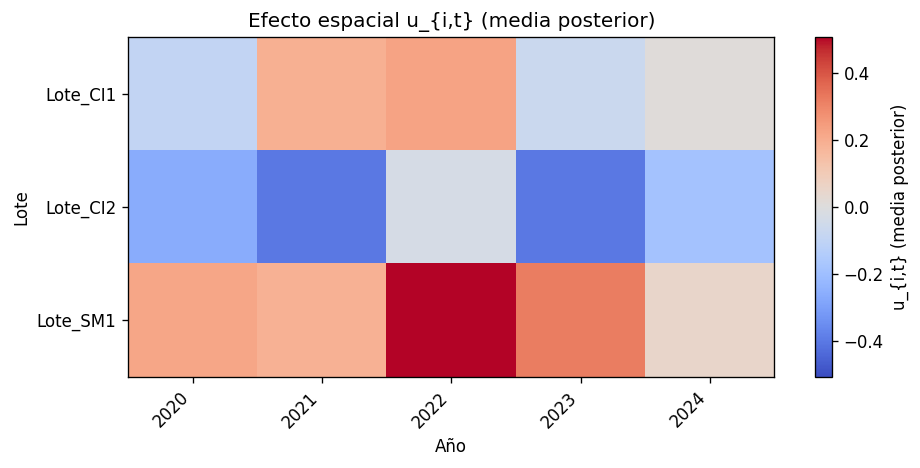

In [ ]:
# ==========================================
# 9.4 HEATMAP lote × año del efecto espacial u_{i,t}
# ==========================================

N, T = Y_mat.shape  # ya lo tenías antes

# Matriz con medias posteriores u_{i,t}
U_mean = np.zeros((N, T))

for t in range(T):
    # u_t tiene dims (chain, draw, N)
    u_t_post = idata.posterior[f"u_{t}"].mean(dim=("chain", "draw")).values  # (N,)
    U_mean[:, t] = u_t_post

# Escala simétrica alrededor de 0 (rojo = alto, azul = bajo)
umax = np.nanmax(np.abs(U_mean))

fig, ax = plt.subplots(figsize=(8, max(4, 0.25*N)), dpi=120)
im = ax.imshow(
    U_mean,
    aspect="auto",
    cmap="coolwarm",
    vmin=-umax,
    vmax=umax
)

# Ejes
ax.set_xticks(np.arange(T))
ax.set_xticklabels(years, rotation=45, ha="right")
ax.set_yticks(np.arange(N))
ax.set_yticklabels(lotes)

ax.set_xlabel("Año")
ax.set_ylabel("Lote")
ax.set_title("Efecto espacial u_{i,t} (media posterior)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("u_{i,t} (media posterior)")

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# 9.5 MAPA FOLIUM – Efecto espacial u_{i,t} por año (capas múltiples)
# ==========================================

# 1) Si no lo tienes aún, construimos GeoDataFrame de lotes en 4326
gdf_lotes = gpd.GeoDataFrame(
    {"lote": lotes,
     "x": coords_lote[:, 0],
     "y": coords_lote[:, 1]},
    geometry=gpd.points_from_xy(coords_lote[:, 0], coords_lote[:, 1]),
    crs="EPSG:3857"
).to_crs(epsg=4326)

gdf_lotes["lon"] = gdf_lotes.geometry.x
gdf_lotes["lat"] = gdf_lotes.geometry.y

# 2) Escala global para todos los años (misma que en el heatmap)
umax = float(np.nanmax(np.abs(U_mean)))
vmin_u, vmax_u = -umax, umax

cmap_u_all = cm.LinearColormap(
    colors=["blue", "cyan", "yellow", "red"],
    vmin=vmin_u, vmax=vmax_u
).to_step(10)
cmap_u_all.caption = "Efecto espacial u_{i,t} (media posterior)"

# 3) Centro del mapa
center_lat = gdf["lat"].mean()
center_lon = gdf["lon"].mean()

m_multi = folium.Map(location=[center_lat, center_lon],
                     zoom_start=13, tiles="CartoDB positron")

# 4) Crear una capa por año
for t in range(T):
    anio = years[t]
    u_t = U_mean[:, t]   # (N,)

    df_layer = gdf_lotes.copy()
    df_layer["u_mean"] = u_t

    fg = folium.FeatureGroup(name=f"Año {anio}")

    for row in df_layer.itertuples():
        color = cmap_u_all(row.u_mean)
        folium.CircleMarker(
            location=[row.lat, row.lon],
            radius=7,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.9,
            popup=(
                f"Lote: {row.lote}<br>"
                f"Año: {anio}<br>"
                f"u_mean: {row.u_mean:.3f}"
            )
        ).add_to(fg)

    fg.add_to(m_multi)

# 5) Añadir leyenda y control de capas
cmap_u_all.add_to(m_multi)
folium.LayerControl(collapsed=False).add_to(m_multi)

m_multi


In [ ]:
# ==========================================
# BLOQUE 10. Sensibilidad a k en Moran global
# ==========================================
for k in [4, 8, 12]:
    Wk = KNN.from_array(coords, k=k)
    Wk.transform = "r"
    mi_k = Moran(z, Wk)
    print(f"k={k}: Moran I={mi_k.I:.3f}, p={mi_k.p_sim:.4f}")


 There are 3 disconnected components.
k=4: Moran I=0.054, p=0.1920
k=8: Moran I=-0.030, p=0.3490
k=12: Moran I=-0.034, p=0.3080


**Conclusiones finales (cinco puntos concretos)**

La distribución de la enfermedad no es aleatoria: los análisis de Moran I, la función K/L de Ripley y los semivariogramas demuestran que la incidencia y la severidad de Colletotrichum en mango de azúcar presentan un fuerte patrón de agregación espacial a distancias cortas e intermedias, consistente con la presencia de focos epidémicos y procesos de dispersión local.

El kriging esférico es el interpolador más adecuado para estos datos: al comparar IDW y kriging con diferentes modelos de variograma, el modelo esférico produce mapas más coherentes con la estructura espacial observada y permite cuantificar la incertidumbre de las predicciones, lo que lo convierte en la herramienta principal para generar mapas de riesgo fitosanitario en esta región.

Los modelos espaciales por lote mejoran la explicación de la severidad media: la autocorrelación en los residuos de la regresión clásica y el mejor desempeño de las variantes SAR/SEM indican que, además de la incidencia, existen procesos espaciales (difusión o factores ambientales compartidos) que influyen en la severidad a escala de lote, por lo que las decisiones de manejo deben considerar explícitamente la estructura espacial.

El modelo espacio–temporal bayesiano permite identificar años y lotes críticos: la descomposición en efectos temporales
𝑤
𝑡
w
t
	​

 y espaciales
𝑢
𝑖
,
𝑡
u
i,t
	​

 muestra que hay años particularmente favorables para la enfermedad y lotes que actúan repetidamente como “hot-spots” de severidad residual. Esta información es clave para priorizar intervenciones de manejo y orientar estudios de factores de riesgo específicos.

El mapa de riesgo puede usarse para diseñar muestreos más eficientes: la estratificación espacial basada en las predicciones de kriging, combinada con selección de puntos mediante k-means, genera un esquema de muestreo estratificado que concentra el esfuerzo en las zonas de alto riesgo sin descuidar las de riesgo medio y bajo. Esto mejora la eficiencia de las campañas de monitoreo y apoya la implementación de sistemas de vigilancia fitosanitaria de precisión en la cadena de mango de azúcar.

**11. Diseño de muestreo espacial óptimo basado en el mapa de riesgo (Bonus)**

Finalmente, utilizando el mapa de kriging de la variable objetivo se construyó una superficie de riesgo interpolado sobre una malla regular. A partir de los cuantiles de la predicción se definieron tres estratos de riesgo (bajo, medio y alto) y se asignó un tamaño de muestra total repartido de manera desigual, priorizando el estrato de alto riesgo. Dentro de cada estrato, se aplicó k-means clustering para seleccionar puntos de muestreo que representaran bien el espacio disponible, tomando como sitios propuestos los puntos más cercanos a los centroides de cada cluster. Este enfoque garantiza que el muestreo no se concentre en unos pocos puntos cercanos, sino que se distribuya de forma razonable dentro de cada estrato de riesgo.

La visualización de los sitios propuestos sobre el mapa de kriging demuestra que el diseño de muestreo resultante cubre adecuadamente las zonas de mayor riesgo sin descuidar los estratos medio y bajo, lo cual es importante para caracterizar correctamente la dinámica de la enfermedad y no sobrestimar la prevalencia. La exportación de estos puntos como capa geoespacial permite su uso directo en QGIS o dispositivos móviles para planificar campañas de monitoreo futuro. En términos prácticos, este bonus muestra cómo los modelos espaciales no son solo herramientas descriptivas, sino que pueden alimentar esquemas de muestreo adaptativo y de vigilancia fitosanitaria más eficientes.

In [ ]:
# ==========================================
# BONUS 1 – Construir DataFrame de la malla de predicciones
# ==========================================
# Usamos el kriging esférico de la variable objetivo `target_var`
# (asegúrate de haber corrido BLOQUE 3 antes)

gx_c, gy_c = np.meshgrid(gridx, gridy, indexing="xy")

df_grid = pd.DataFrame({
    "x": gx_c.ravel(),
    "y": gy_c.ravel(),
    "pred": z_sph.T.ravel()   # cuidado: z_sph viene como [nx, ny], por eso el .T
})

print(df_grid.head())
print("Puntos en la malla:", len(df_grid))


              x             y      pred
0 -8.266550e+06  1.228501e+06  5.187346
1 -8.266405e+06  1.228501e+06  5.076930
2 -8.266260e+06  1.228501e+06  5.208849
3 -8.266115e+06  1.228501e+06  4.585666
4 -8.265970e+06  1.228501e+06  3.171726
Puntos en la malla: 6400


In [ ]:
# ==========================================
# BONUS 2 – Definir estratos de riesgo según predicción
# ==========================================
# Usamos cuantiles 0.33 y 0.66 como cortes (puedes jugar con esto)
q_low, q_high = df_grid["pred"].quantile([0.33, 0.66])
print("Cortes de estratos:", q_low, q_high)

def clasificar_riesgo(v):
    if v < q_low:
        return "bajo"
    elif v < q_high:
        return "medio"
    else:
        return "alto"

df_grid["estrato"] = df_grid["pred"].apply(clasificar_riesgo)

df_grid["estrato"].value_counts()


Cortes de estratos: 5.22479149967744 5.22479149967744


,count
estrato,
alto,6079
bajo,321


In [ ]:
# ==========================================
# BONUS 3 – Asignar tamaño de muestra por estrato
# ==========================================
N_total = 60  # número total de sitios a muestrear (ajusta según tu logística)

# Proporciones recomendadas: más puntos en alto riesgo
prop = {
    "bajo": 0.2,
    "medio": 0.3,
    "alto": 0.5
}

n_por_estrato = {
    e: max(3, int(N_total * p))  # mínimo 3 puntos por estrato
    for e, p in prop.items()
}

print("Tamaño de muestra por estrato:")
for e, n in n_por_estrato.items():
    print(f"  {e}: {n} puntos")


Tamaño de muestra por estrato:
  bajo: 12 puntos
  medio: 18 puntos
  alto: 30 puntos


In [ ]:
# ==========================================
# BONUS 4 – Seleccionar sitios de muestreo (k-means por estrato)
# ==========================================
from sklearn.cluster import KMeans

muestras = []

for estrato, n_samples in n_por_estrato.items():
    sub = df_grid[df_grid["estrato"] == estrato].copy()
    if len(sub) < n_samples:
        # si hay muy pocos píxeles, tomamos todos
        print(f"⚠️ Estrato {estrato} tiene pocos puntos ({len(sub)}), se toman todos.")
        sub["cluster"] = np.arange(len(sub))
        muestras.append(sub)
        continue

    coords_sub = sub[["x", "y"]].values
    km = KMeans(n_clusters=n_samples, random_state=2025, n_init=10)
    sub["cluster"] = km.fit_predict(coords_sub)

    # Para cada cluster, tomar el punto más cercano al centroide
    centroids = km.cluster_centers_
    for k in range(n_samples):
        idx_k = sub["cluster"] == k
        sub_k = sub[idx_k]
        if sub_k.empty:
            continue
        # punto más cercano al centroide
        dists = np.linalg.norm(sub_k[["x", "y"]].values - centroids[k], axis=1)
        i_min = sub_k.index[np.argmin(dists)]
        muestras.append(sub.loc[[i_min]])

df_muestreo = pd.concat(muestras, ignore_index=True)

print("Total de sitios de muestreo propuestos:", len(df_muestreo))
df_muestreo.head()


⚠️ Estrato medio tiene pocos puntos (0), se toman todos.
Total de sitios de muestreo propuestos: 42


,x,y,pred,estrato,cluster
0,-8.265535e+06,1.231013e+06,3.737906,bajo,0
1,-8.262346e+06,1.246798e+06,5.208885,bajo,1
2,-8.255678e+06,1.252897e+06,4.609672,bajo,2
3,-8.262781e+06,1.242134e+06,4.751984,bajo,3
4,-8.266115e+06,1.236035e+06,2.001556,bajo,4


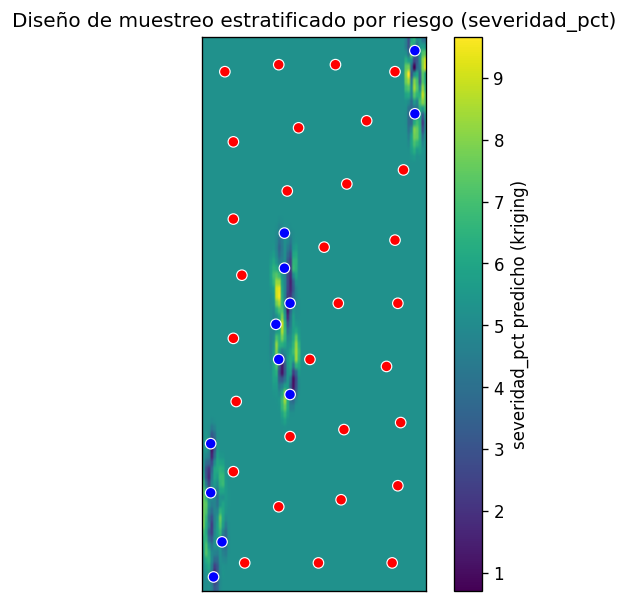

In [ ]:
# ==========================================
# BONUS 5 – Visualizar sitios de muestreo sobre el mapa de riesgo
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=120)

im = ax.imshow(
    z_sph.T,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    cmap="viridis"
)
plt.colorbar(im, ax=ax, label=f"{target_var} predicho (kriging)")

# Puntos de muestreo
scatter = ax.scatter(
    df_muestreo["x"], df_muestreo["y"],
    c=df_muestreo["estrato"].map({"bajo": "blue", "medio": "orange", "alto": "red"}),
    s=40, edgecolor="white", linewidth=0.7,
    label="Sitios de muestreo"
)

ax.set_title(f"Diseño de muestreo estratificado por riesgo ({target_var})")
ax.set_xticks([])
ax.set_yticks([])

plt.show()


In [ ]:
# ==========================================
# BONUS 6 – Exportar sitios de muestreo como capa espacial
# ==========================================
gdf_muestreo = gpd.GeoDataFrame(
    df_muestreo.copy(),
    geometry=gpd.points_from_xy(df_muestreo["x"], df_muestreo["y"]),
    crs=gdf.crs  # mismo CRS métrico que tus datos originales
)

salida_gpkg = "muestreo_optimo_colletotrichum.gpkg"
gdf_muestreo.to_file(salida_gpkg, layer="muestreo_optimo", driver="GPKG")

print("Archivo de muestreo guardado en:", salida_gpkg)


Archivo de muestreo guardado en: muestreo_optimo_colletotrichum.gpkg
